In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
df = pd.read_csv("SEO_main1.csv")

In [12]:
df.head()

,Keyword ID,Keyword,Position,Previous Position,Search Volume,Keyword Difficulty,CPC,Traffic,Traffic %,Competition,...,Timestamp,SERP Features,Keyword Intent,Position Type,Ranking Change,Opportunity Score,intent ID,position id,trend id,serp id
0,1,excel course,95,88,684,68.9,8.19,7,1.02,0.45,...,2026-09-16,Image Pack,Informational,Organic,-7,11.23,1,1,1,5
1,2,customer analytics best practices,29,28,7157,79.5,9.15,448,6.26,0.31,...,2026-02-22,Sitelinks,Informational,Organic,-1,23.71,1,1,2,1
2,3,content marketing templates,34,44,121,52.9,11.68,6,4.96,0.83,...,2026-04-09,Reviews,Informational,Organic,10,17.01,1,1,3,6
3,4,seo analytics tools,30,42,193,46.3,10.04,11,5.70,0.68,...,2026-02-06,Image Pack,Commercial,Organic,12,19.53,2,1,2,5
4,5,machine learning jobs,60,57,1392,61.2,6.77,34,2.44,0.78,...,2026-06-11,Video,Informational,Organic,-3,15.71,1,1,1,4


In [13]:
df.shape

(5000, 22)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Keyword ID          5000 non-null   int64  
 1   Keyword             5000 non-null   object 
 2   Position            5000 non-null   int64  
 3   Previous Position   5000 non-null   int64  
 4   Search Volume       5000 non-null   int64  
 5   Keyword Difficulty  5000 non-null   float64
 6   CPC                 5000 non-null   float64
 7   Traffic             5000 non-null   int64  
 8   Traffic %           5000 non-null   float64
 9   Competition         5000 non-null   float64
 10  Number of Results   5000 non-null   int64  
 11  Trends              5000 non-null   object 
 12  Timestamp           5000 non-null   object 
 13  SERP Features       4268 non-null   object 
 14  Keyword Intent      5000 non-null   object 
 15  Position Type       5000 non-null   object 
 16  Rankin

In [15]:
df.isnull().sum()

Keyword ID              0
Keyword                 0
Position                0
Previous Position       0
Search Volume           0
Keyword Difficulty      0
CPC                     0
Traffic                 0
Traffic %               0
Competition             0
Number of Results       0
Trends                  0
Timestamp               0
SERP Features         732
Keyword Intent          0
Position Type           0
Ranking Change          0
Opportunity Score       0
intent ID               0
position id             0
trend id                0
serp id                 0
dtype: int64

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df["Search Volume"] = pd.to_numeric(
    df["Search Volume"], errors="coerce"
)

In [18]:
df["Traffic"] = pd.to_numeric(
    df["Traffic"], errors="coerce"
)

In [19]:
df.groupby("Keyword Intent").agg(
    Keywords=("Keyword", "count"),
    Traffic=("Traffic", "sum"),
    Avg_Search_Volume=("Search Volume", "mean")
).sort_values("Traffic", ascending=False)

,Keywords,Traffic,Avg_Search_Volume
Keyword Intent,,,
Informational,2103,590027,4505.542083
Commercial,1405,443744,4515.651957
Transactional,983,276217,4427.296033
Navigational,509,133540,4816.438114


In [20]:
top_traffic = df.nlargest(10, "Traffic")

top_traffic[["Keyword", "Traffic"]]

,Keyword,Traffic
2969,power bi training,7441
2249,reporting software,7331
1736,digital marketing online,7330
1886,data analyst interview questions,7288
3926,customer analytics examples,6106
3462,marketing analytics certification,6068
3213,business intelligence jobs,5995
1284,digital marketing tools,5802
2770,reporting for beginners,5608
4993,keyword research software,5559


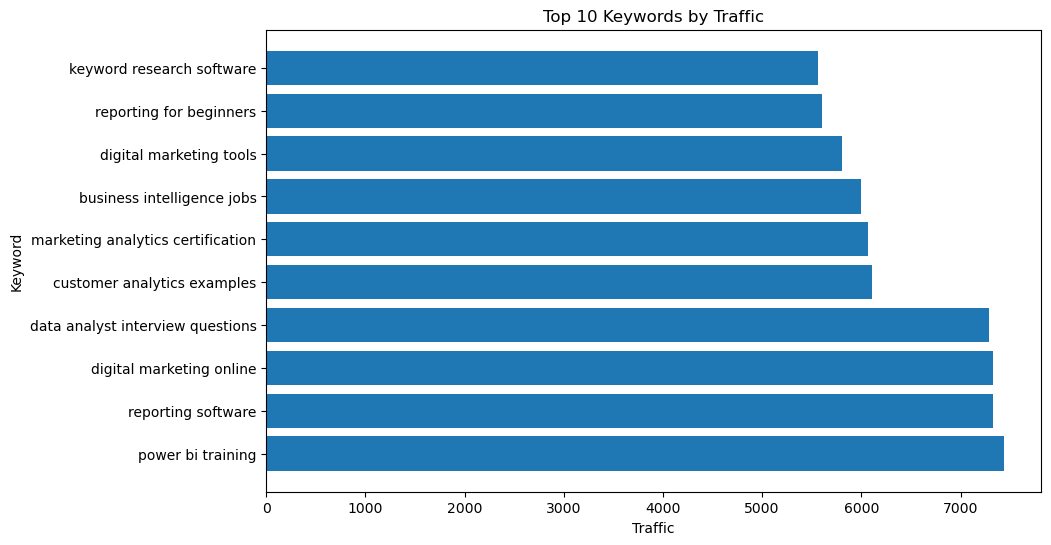

In [21]:
plt.figure(figsize=(10,6))

plt.barh(
    top_traffic["Keyword"],
    top_traffic["Traffic"]
)

plt.xlabel("Traffic")
plt.ylabel("Keyword")
plt.title("Top 10 Keywords by Traffic")

plt.show()

In [22]:
df["Ranking Improvement"] = (
    df["Previous Position"] - df["Position"]
)

In [23]:
df.nlargest(
    10,
    "Ranking Improvement"
)[
    ["Keyword", "Previous Position", "Position", "Ranking Improvement"]
]

,Keyword,Previous Position,Position,Ranking Improvement
36,data visualization templates,93,78,15
38,data science certification,71,56,15
60,dashboard project,97,82,15
91,marketing analytics online,69,54,15
127,reporting training,44,29,15
136,power bi for beginners,68,53,15
179,data analyst jobs,79,64,15
197,data visualization best practices,97,82,15
202,data science course,71,56,15
397,reporting templates,81,66,15


In [24]:
df.columns

Index(['Keyword ID', 'Keyword', 'Position', 'Previous Position',
       'Search Volume', 'Keyword Difficulty', 'CPC', 'Traffic', 'Traffic %',
       'Competition', 'Number of Results', 'Trends', 'Timestamp',
       'SERP Features', 'Keyword Intent', 'Position Type', 'Ranking Change',
       'Opportunity Score', 'intent ID', 'position id', 'trend id', 'serp id',
       'Ranking Improvement'],
      dtype='object')

In [25]:
df[[
    "Keyword",
    "Search Volume",
    "Keyword Difficulty",
    "Position",
    "Traffic"
]].head()

,Keyword,Search Volume,Keyword Difficulty,Position,Traffic
0,excel course,684,68.9,95,7
1,customer analytics best practices,7157,79.5,29,448
2,content marketing templates,121,52.9,34,6
3,seo analytics tools,193,46.3,30,11
4,machine learning jobs,1392,61.2,60,34


In [26]:
df["Search Volume"] = pd.to_numeric(
    df["Search Volume"],
    errors="coerce"
)

df["Keyword Difficulty"] = pd.to_numeric(
    df["Keyword Difficulty"],
    errors="coerce"
)

df["Position"] = pd.to_numeric(
    df["Position"],
    errors="coerce"
)

df["Traffic"] = pd.to_numeric(
    df["Traffic"],
    errors="coerce"
)

In [27]:
df = df.dropna(
    subset=[
        "Keyword",
        "Search Volume",
        "Keyword Difficulty",
        "Position"
    ]
)

In [28]:
df["Search Volume Score"] = (
    df["Search Volume"] / df["Search Volume"].max()
) * 40

In [29]:
df["Difficulty Score"] = (
    1 - (
        df["Keyword Difficulty"] /
        df["Keyword Difficulty"].max()
    )
) * 30

In [30]:
df["Position Opportunity Score"] = np.where(
    (df["Position"] >= 11) &
    (df["Position"] <= 30),
    30,
    0
)

In [31]:
df["SEO Opportunity Score"] = (
    df["Search Volume Score"]
    + df["Difficulty Score"]
    + df["Position Opportunity Score"]
)

In [32]:
df["Opportunity Level"] = pd.cut(
    df["SEO Opportunity Score"],
    bins=[-1, 40, 70, 100],
    labels=["Low", "Medium", "High"]
)

In [33]:
top_opportunities = df.sort_values(
    "SEO Opportunity Score",
    ascending=False
).head(20)

In [34]:
top_opportunities[[
    "Keyword",
    "Search Volume",
    "Keyword Difficulty",
    "Position",
    "Traffic",
    "SEO Opportunity Score",
    "Opportunity Level"
]]

,Keyword,Search Volume,Keyword Difficulty,Position,Traffic,SEO Opportunity Score,Opportunity Level
2627,seo analytics certification,24397,10.3,17,4077,95.370595,High
2370,power bi training,24579,17.8,13,3774,93.160070,High
2636,mysql software,24219,21.1,13,4056,91.487483,High
2648,machine learning online,24244,28.7,21,2126,88.993912,High
205,dashboard tutorial,21010,16.9,20,2900,87.783502,High
728,content marketing interview questions,24484,34.6,11,5270,87.408971,High
2891,marketing analytics training,22508,25.7,26,1982,87.232769,High
1534,tableau project,24393,38.8,16,3589,85.864233,High
4462,python pandas tutorial,22840,33.8,15,3455,85.060822,High
3571,google analytics training,22197,32.2,14,3091,84.571450,High


In [35]:
top_opportunities[[
    "Keyword",
    "Search Volume",
    "Keyword Difficulty",
    "Position",
    "Traffic",
    "SEO Opportunity Score",
    "Opportunity Level"
]].reset_index(drop=True)

,Keyword,Search Volume,Keyword Difficulty,Position,Traffic,SEO Opportunity Score,Opportunity Level
0,seo analytics certification,24397,10.3,17,4077,95.370595,High
1,power bi training,24579,17.8,13,3774,93.160070,High
2,mysql software,24219,21.1,13,4056,91.487483,High
3,machine learning online,24244,28.7,21,2126,88.993912,High
4,dashboard tutorial,21010,16.9,20,2900,87.783502,High
5,content marketing interview questions,24484,34.6,11,5270,87.408971,High
6,marketing analytics training,22508,25.7,26,1982,87.232769,High
7,tableau project,24393,38.8,16,3589,85.864233,High
8,python pandas tutorial,22840,33.8,15,3455,85.060822,High
9,google analytics training,22197,32.2,14,3091,84.571450,High


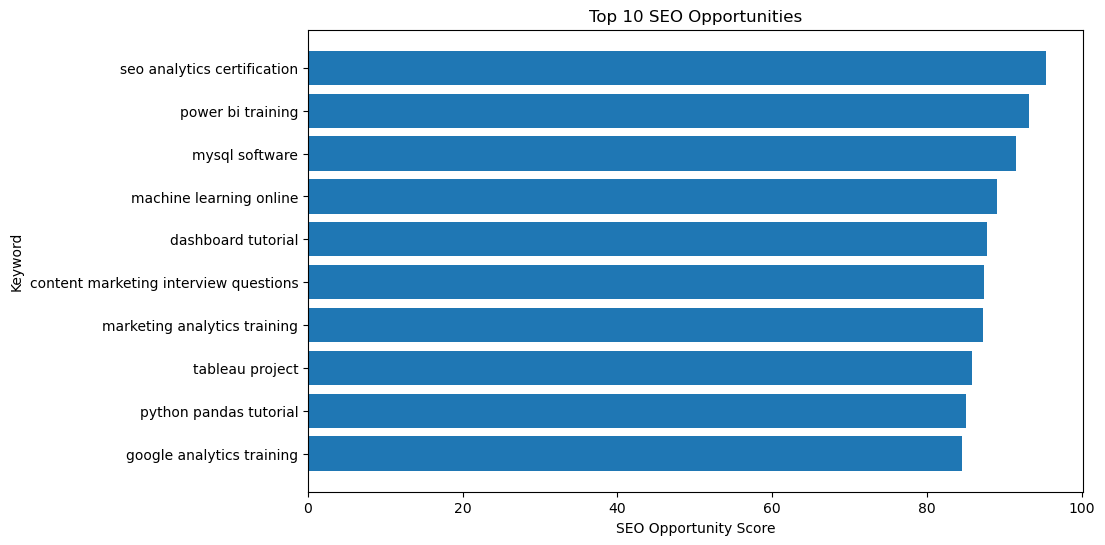

In [36]:
top10 = top_opportunities.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top10["Keyword"],
    top10["SEO Opportunity Score"]
)

plt.xlabel("SEO Opportunity Score")
plt.ylabel("Keyword")
plt.title("Top 10 SEO Opportunities")

plt.gca().invert_yaxis()

plt.show()

In [37]:
top_opportunities.to_csv(
    "keyword_opportunities.csv",
    index=False
)

In [38]:
df.columns

Index(['Keyword ID', 'Keyword', 'Position', 'Previous Position',
       'Search Volume', 'Keyword Difficulty', 'CPC', 'Traffic', 'Traffic %',
       'Competition', 'Number of Results', 'Trends', 'Timestamp',
       'SERP Features', 'Keyword Intent', 'Position Type', 'Ranking Change',
       'Opportunity Score', 'intent ID', 'position id', 'trend id', 'serp id',
       'Ranking Improvement', 'Search Volume Score', 'Difficulty Score',
       'Position Opportunity Score', 'SEO Opportunity Score',
       'Opportunity Level'],
      dtype='object')

In [39]:
top_opportunities = df.sort_values(
    "SEO Opportunity Score",
    ascending=False
).head(20)

In [40]:
top_opportunities[[
    "Keyword",
    "Search Volume",
    "Keyword Difficulty",
    "Position",
    "Traffic",
    "SEO Opportunity Score",
    "Opportunity Level"
]].reset_index(drop=True)

,Keyword,Search Volume,Keyword Difficulty,Position,Traffic,SEO Opportunity Score,Opportunity Level
0,seo analytics certification,24397,10.3,17,4077,95.370595,High
1,power bi training,24579,17.8,13,3774,93.160070,High
2,mysql software,24219,21.1,13,4056,91.487483,High
3,machine learning online,24244,28.7,21,2126,88.993912,High
4,dashboard tutorial,21010,16.9,20,2900,87.783502,High
5,content marketing interview questions,24484,34.6,11,5270,87.408971,High
6,marketing analytics training,22508,25.7,26,1982,87.232769,High
7,tableau project,24393,38.8,16,3589,85.864233,High
8,python pandas tutorial,22840,33.8,15,3455,85.060822,High
9,google analytics training,22197,32.2,14,3091,84.571450,High


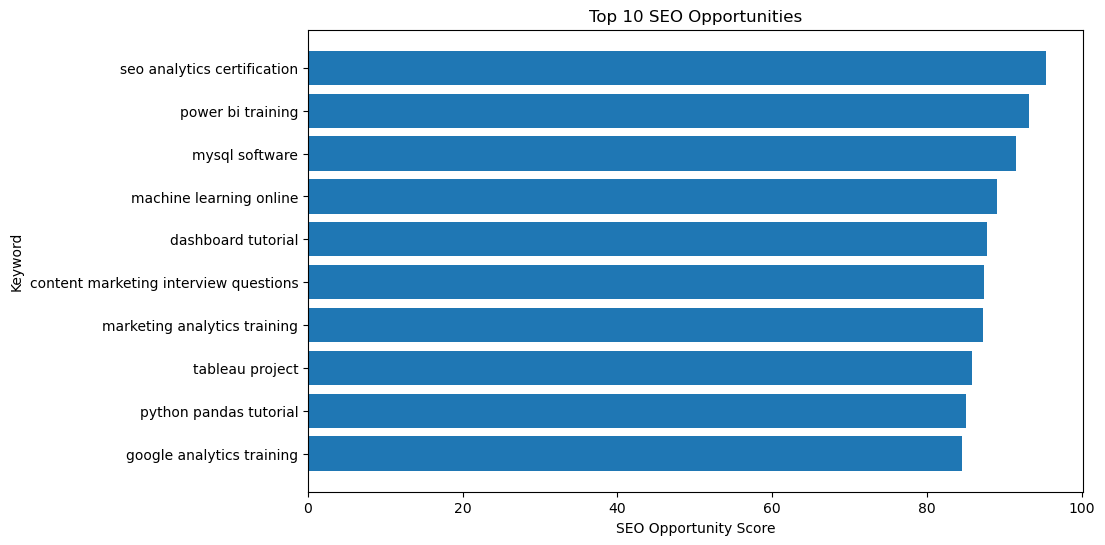

In [41]:
top10 = top_opportunities.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top10["Keyword"],
    top10["SEO Opportunity Score"]
)

plt.xlabel("SEO Opportunity Score")
plt.ylabel("Keyword")
plt.title("Top 10 SEO Opportunities")

plt.gca().invert_yaxis()

plt.show()

In [42]:
top_opportunities.to_csv(
    "keyword_opportunities.csv",
    index=False
)

In [43]:
import os

os.path.exists("keyword_opportunities.csv")

True

In [44]:
top10 = top_opportunities.head(10)

top10[[
    "Keyword",
    "Search Volume",
    "Keyword Difficulty",
    "Position",
    "Traffic",
    "SEO Opportunity Score",
    "Opportunity Level"
]]

,Keyword,Search Volume,Keyword Difficulty,Position,Traffic,SEO Opportunity Score,Opportunity Level
2627,seo analytics certification,24397,10.3,17,4077,95.370595,High
2370,power bi training,24579,17.8,13,3774,93.160070,High
2636,mysql software,24219,21.1,13,4056,91.487483,High
2648,machine learning online,24244,28.7,21,2126,88.993912,High
205,dashboard tutorial,21010,16.9,20,2900,87.783502,High
728,content marketing interview questions,24484,34.6,11,5270,87.408971,High
2891,marketing analytics training,22508,25.7,26,1982,87.232769,High
1534,tableau project,24393,38.8,16,3589,85.864233,High
4462,python pandas tutorial,22840,33.8,15,3455,85.060822,High
3571,google analytics training,22197,32.2,14,3091,84.571450,High


In [45]:
ai_data = top10[[
    "Keyword",
    "Search Volume",
    "Keyword Difficulty",
    "Position",
    "Traffic",
    "SEO Opportunity Score",
    "Opportunity Level"
]].to_string(index=False)

print(ai_data)

                              Keyword  Search Volume  Keyword Difficulty  Position  Traffic  SEO Opportunity Score Opportunity Level
          seo analytics certification          24397                10.3        17     4077              95.370595              High
                    power bi training          24579                17.8        13     3774              93.160070              High
                       mysql software          24219                21.1        13     4056              91.487483              High
              machine learning online          24244                28.7        21     2126              88.993912              High
                   dashboard tutorial          21010                16.9        20     2900              87.783502              High
content marketing interview questions          24484                34.6        11     5270              87.408971              High
         marketing analytics training          22508                2